In [1]:
print("hello world")

hello world


In [2]:
import sys
sys.modules.pop('feature_transformer', None)
sys.modules.pop('utils.data_quality', None)
sys.modules.pop('utils.stats_dataset', None)
sys.modules.pop('utils.algo_prediction', None)

In [28]:
from utils.feature_loader import load_feature_lists
from utils.data_quality import nettoyer_nan_par_colonne
from utils.data_quality import nettoyer_lignes_vides
import pandas as pd
df_groh = pd.read_excel(r"C:\Users\romai\Desktop\travail\Copie de BAZEA.xlsx")

df_groh,index_a_drop = nettoyer_lignes_vides(df_groh)
feature_lists = load_feature_lists("utils/features_grroh.json",available_columns = df_groh.columns)

features_grroh = df_groh[feature_lists["Liste_features_grroh"] + feature_lists["Liste_features_scan_radio"]]
features_etiology = df_groh[feature_lists["features_etiology"]]
features_death = df_groh[feature_lists["death"]]
print(features_grroh.columns)


Index(['SEXE', 'age', 'delai_hop_rea', 'delai_symptome_rea',
       'delai_diag_patho', 'Hemopathie', 'REM', 'NCUR', 'AUTOGREFFE',
       'ALLOGREFFE', 'DCHIM', 'LCHIM', 'Maladie_syst', 'TUMEURSOLIDE',
       'greffe_organe_solide', 'IMMUNSUP', 'Type_IS', 'prphy_pcp',
       'prophy_antifung', 'prophy_virus', 'GLASGOW', 'SOFA', 'HEMOPTYSIE',
       'FRMAX', 'SAO2MIN', 'TEMPMAX', 'SPAO2FIO2', 'NEUTROPENIE', 'LEUCO',
       'RADIOTHOR_CHOICE_0', 'RADIOTHOR_CHOICE_1', 'RADIOTHOR_CHOICE_2',
       'RADIOTHOR_CHOICE_3', 'RADIOTHOR_CHOICE_4', 'RADIOTHOR_CHOICE_5',
       'RADIOTHOR_CHOICE_6', 'RADIOTHOR_CHOICE_7', 'RTDMTHOR_CHOICE_0',
       'RTDMTHOR_CHOICE_1', 'RTDMTHOR_CHOICE_2', 'RTDMTHOR_CHOICE_3',
       'RTDMTHOR_CHOICE_4', 'RTDMTHOR_CHOICE_5', 'RTDMTHOR_CHOICE_6',
       'RTDMTHOR_CHOICE_7', 'RTDMTHOR_CHOICE_8', 'RTDMTHOR_CHOICE_9',
       'RTDMTHOR_CHOICE_10', 'RTDMTHOR_CHOICE_11', 'RTDMTHOR_CHOICE_12',
       'RTDMTHOR_CHOICE_13', 'RTDMTHOR_CHOICE_14', 'RTDMTHOR_CHOICE_15',
       

In [33]:

sys.modules.pop('utils.utils_grroh',None)
from utils.utils_grroh import construire_mapping_renommage,renommer_df

mapping_df, rename_dict = construire_mapping_renommage(feature_lists["Liste_features_grroh"])
df_renomme = renommer_df(features_grroh, mapping_df)

L_fill_mediane = ["Age"	,"Time H-ICU"	,"TIME SYMPTOMES-ICU","SOFA_score","Neutrophils","Temp","Sp02","PaO2/FiO2 VALUE VALUE","Resp_rate","Leukocytes","Quad_no"]
strategie_fill_nan = {
    col: "median" if col in L_fill_mediane else "zero"
    for col in df_renomme.columns
}
features_grroh_clean = nettoyer_nan_par_colonne(df_renomme,strategie_fill_nan)

print(df_renomme.columns)

🔹 Age → NaN remplacés par la médiane (62.0)
🔹 TIME SYMPTOMES-ICU → NaN remplacés par la médiane (1.0)
🔹 SOFA_score → NaN remplacés par la médiane (6.0)
🔹 Resp_rate → NaN remplacés par la médiane (29.0)
🔹 Temp → NaN remplacés par la médiane (38.0)
🔹 Neutrophils → NaN remplacés par la médiane (0.0)
🔹 Leukocytes → NaN remplacés par la médiane (5.0)
🔹 PaO2/FiO2 VALUE VALUE → NaN remplacés par la médiane (136.0)

✅ Nettoyage terminé. NaN restants : 0
Index(['Sex', 'Age', 'delai_hop_rea', 'TIME SYMPTOMES-ICU', 'Time  DG-ICU',
       'Hem_mal', 'REM', 'NCUR', 'AUTOGREFFE', 'ALLOGREFFE', 'DCHIM', 'LCHIM',
       'Sys_dis', 'Solid_tumor', 'Organ_transpl', 'IMMUNSUP', 'Type_IS',
       'Prophylaxis_pneumocystis', 'Prophylaxis_antifungal',
       'Prophylaxis_viral', 'GLASGOW', 'SOFA_score', 'Hemoptysis', 'Resp_rate',
       'SpO2', 'Temp', 'SPAO2FIO2', 'Neutrophils', 'Leukocytes',
       'RADIOTHOR_CHOICE_0', 'RADIOTHOR_CHOICE_1', 'RADIOTHOR_CHOICE_2',
       'RADIOTHOR_CHOICE_3', 'RADIOTHOR_CHO

In [ ]:
for 

In [34]:
mapping_df

,target,source,type,present_in_df
0,Sex,SEXE,rename,True
1,Age,age,rename,True
2,Time H-ICU,Time H-ICU,rename,False
3,TIME SYMPTOMES-ICU,delai_symptome_rea,rename,True
4,Time DG-ICU,delai_diag_patho,rename,True
5,Hem_mal,Hemopathie,rename,True
6,HSCT_BMT,"[AUTOGREFFE, ALLOGREFFE]",derive_multi,True
7,Sys_dis,Maladie_syst,rename,True
8,Solid_tumor,TUMEURSOLIDE,rename,True
9,Organ_transpl,greffe_organe_solide,rename,True


# Efraim 

In [29]:
FEATURE_CONFIG_PATH = "utils/feature_columns.json"
feature_lists_efraim = load_feature_lists(FEATURE_CONFIG_PATH)
Liste_features_simple = feature_lists_efraim["Liste_features_simple"]
features_radiology_dysfunction = feature_lists_efraim["features_radiology_dysfunction"]
features_etiology = feature_lists_efraim["features_etiology"]
features_death = feature_lists_efraim["death"]
# Charger le fichier Excel
df_efraim = pd.read_excel(r"C:\Users\romai\Desktop\travail\EFRAIM3 JD VANCE.xlsx")

# séparer colonnes explicatives et etiology
df_efraim = df_efraim[df_efraim['Etiology_Undetermined cause_Definitive diagnosis'] != 1]
features_etiology.remove('Etiology_Undetermined cause_Definitive diagnosis')
Liste_features = Liste_features_simple + features_radiology_dysfunction
df_col_utils = df_efraim[Liste_features]
df_category = df_efraim[features_etiology]
df_death = df_efraim[features_death]

from utils.feature_transformer import transform_features, _convert_all_columns_to_numeric
from utils.data_quality import nettoyer_nan_par_colonne
L_fill_mediane = ["Age"	,"Time H-ICU"	,"TIME SYMPTOMES-ICU","SOFA_score","Neutrophils","Temp","Sp02","PaO2/FiO2 VALUE VALUE","Resp_rate","Leukocytes","Quad_no"]
strategie_fill_nan = {
    col: "median" if col in L_fill_mediane else "zero"
    for col in Liste_features
}

df_col_utils = nettoyer_nan_par_colonne(df_col_utils,strategie_fill_nan)
df_features_clean = transform_features(df_col_utils)
df_features_clean = _convert_all_columns_to_numeric(df_features_clean)

🔹 Age → NaN remplacés par la médiane (64.0)
🔹 Time H-ICU → NaN remplacés par la médiane (2.0)
🔹 TIME SYMPTOMES-ICU → NaN remplacés par la médiane (2.0)
🔹 SOFA_score → NaN remplacés par la médiane (7.0)
🔹 Resp_rate → NaN remplacés par la médiane (30.0)
🔹 Temp → NaN remplacés par la médiane (37.3)
🔹 PaO2/FiO2 VALUE VALUE → NaN remplacés par la médiane (88.0)
🔹 Neutrophils → NaN remplacés par la médiane (7.17)
🔹 Leukocytes → NaN remplacés par la médiane (9.51)
🔹 Quad_no → NaN remplacés par la médiane (3.0)

✅ Nettoyage terminé. NaN restants : 0


# Comparaison dataframes

In [26]:
def comparer_colonnes(df1, df2):
    cols_df1 = set(df1.columns)
    cols_df2 = set(df2.columns)

    colonnes_communes = sorted(cols_df1 & cols_df2)
    colonnes_uniquement_df1 = sorted(cols_df1 - cols_df2)
    colonnes_uniquement_df2 = sorted(cols_df2 - cols_df1)

    return {
        "communes": colonnes_communes,
        "uniquement_df1": colonnes_uniquement_df1,
        "uniquement_df2": colonnes_uniquement_df2
    }
comparer_colonnes(df_col_utils,features_grroh_clean)

{'communes': ['Age',
  'Chemotherapy',
  'Dis_status HEM',
  'HSCT_BMT',
  'Hem_mal',
  'Hemoptysis',
  'Immuno_drugs',
  'Leukocytes',
  'Neutrophils',
  'Organ_transpl',
  'PaO2/FiO2 VALUE VALUE',
  'Prophylaxis_antifungal',
  'Prophylaxis_pneumocystis',
  'Prophylaxis_viral',
  'Resp_rate',
  'SOFA_score',
  'Sex',
  'Solid_tumor',
  'SpO2',
  'Sys_dis',
  'TIME SYMPTOMES-ICU',
  'Temp',
  'Time  DG-ICU'],
 'uniquement_df1': ['Alveolar_cons',
  'Alveolar_xray',
  'CT_Excavation',
  'CT_Pleural_eff',
  'CT_nodules#Centrolobular',
  'CT_nodules#Peribronchovascular',
  'CT_nodules#Pleural',
  'Carttcells',
  'Crazy_paving',
  'Drug_induced',
  'Excavation',
  'Ground_glass_op',
  'GvHD',
  'Halo_sign',
  'Ibr_Flu_Met',
  'Immunotherapy',
  'Interst_xray',
  'Lymph_bulky',
  'Nodules',
  'Pleural_eff',
  'Prophylaxis_bacterial',
  'Quad_no',
  'SOFA_Nervous',
  'Septal_line',
  'Septic_shock',
  'Steroids_YN',
  'Tar_ther',
  'Time H-ICU',
  'Vaccins#COVID',
  'Vaccins#Flu',
  'Vaccins#

In [ ]:
df_groh.columns 

Index(['Study', 'PATIENT', 'CENTRE', 'SEXE', 'DATNAI', 'age', 'DATINC',
       'DATADMHOSPI', 'DATADMREA', 'DSORTREA',
       ...
       'Pathog√®ne.1.bis', 'Pathog√®ne.2.bis', 'Pathog√®ne.3.bis',
       'DIAGNOSTIC.DEF.1.x', 'DIAGNOSTIC.DEF.2.x', 'DIAGNOSTIC.DEF.3.x',
       'PATHOGENE.DEF.1', 'PATHOGENE.DEF.2', 'PATHOGENE.DEF.3',
       'Unnamed: 194'],
      dtype='object', length=195)

In [6]:
df["DIAGPRINCIPAL_final.x"].value_counts()

DIAGPRINCIPAL_final.x
2               438
0               411
BACT            261
BACT DOCU       184
UNDETERMINED    176
               ... 
ENTEROVIRUS       1
coronavirus       1
rhinovirus        1
trichosporon      1
INFLuenza         1
Name: count, Length: 75, dtype: int64

In [7]:
df.dtypes[30:50]


TYPTRANSPL          object
DATGREFFE           object
Maladie_syst         int64
type_MS             object
CORTICO            float64
MDOSCORT            object
IMMUNSUP           float64
Type_IS             object
remarques_TTT       object
LCHIM              float64
NCUR               float64
REM                 object
AUTOGREFFE         float64
ALLOGREFFE         float64
DATALLO             object
DATAUTO             object
DCHIM               object
PS                  object
prophy_antifung    float64
prphy_pcp          float64
dtype: object

# Graphique de nom de maladie du sang

NameError: name 'plt' is not defined

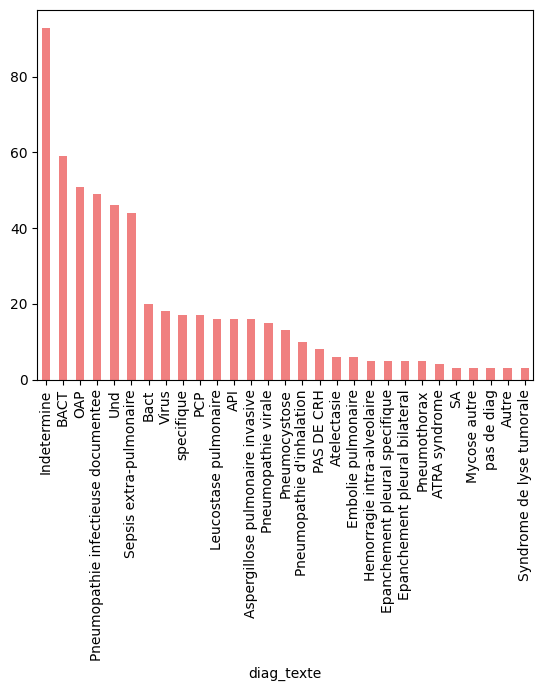

In [ ]:
df["diag_texte"].value_counts()[1:30].plot(kind='bar', color='lightcoral')
import matplotlib.pyplot as plt
plt.title("Distribution des diagnostiques")
plt.xlabel("diagnostiques")
plt.ylabel("Occurence")
plt.xticks(rotation=45, ha='right')
plt.show()